# **Importing the Dependencies**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# **Data Collection & Processing**

In [51]:
# loading the data from sklearn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [52]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [53]:
# loading the data to a data frame
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [54]:
# print the first 5 rows of the dataframe
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [55]:
# adding the 'target' column to the data frame
data_frame['label'] = breast_cancer_dataset.target

In [56]:
# print last 5 rows of the dataframe
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [57]:
# number of rows and columns in the dataset
data_frame.shape

(569, 31)

In [58]:
# getting some information about the data
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [59]:
# checking for missing values
data_frame.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [60]:
# statistical measures about the data
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [61]:
# checking the distribution of Target Varibale
data_frame['label'].value_counts()

,count
label,
1,357
0,212


In [62]:
data_frame.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


# **Separating the features and target**

In [63]:
X = data_frame.drop(columns='label', axis=1)
y = data_frame['label']

In [64]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [65]:
y

,label
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [67]:
print(X.shape, X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


In [68]:
# Standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_test_std = scaler.transform(X_test)

# **Building the Neural Network**

In [69]:
# Setting seed for reproducibility
torch.manual_seed(3)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [70]:
# Define the Neural Network model
class BreastCancerNN(nn.Module):
    def __init__(self, input_size=30, hidden_size=20, output_size=2):
        super(BreastCancerNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Create model instance
model = BreastCancerNN().to(device)
print(model)

BreastCancerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=30, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=2, bias=True)
  (sigmoid): Sigmoid()
)


In [71]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [72]:
# Prepare data for PyTorch - split training data for validation
from sklearn.model_selection import train_test_split as val_split

X_train_final, X_val, Y_train_final, Y_val = val_split(X_train_std, y_train.values, test_size=0.1, random_state=2)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_final).to(device)
Y_train_tensor = torch.LongTensor(Y_train_final).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
Y_val_tensor = torch.LongTensor(Y_val).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training the Neural Network
epochs = 10
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = correct / total
    train_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, Y_val_tensor).item()
        _, val_predicted = torch.max(val_outputs.data, 1)
        val_accuracy = (val_predicted == Y_val_tensor).sum().item() / Y_val_tensor.size(0)

    history['accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}')

Epoch 1/10 - loss: 0.6675 - accuracy: 0.7946 - val_loss: 0.6488 - val_accuracy: 0.8913
Epoch 2/10 - loss: 0.6274 - accuracy: 0.9120 - val_loss: 0.6078 - val_accuracy: 0.9348
Epoch 3/10 - loss: 0.5894 - accuracy: 0.9340 - val_loss: 0.5688 - val_accuracy: 0.9348
Epoch 4/10 - loss: 0.5525 - accuracy: 0.9340 - val_loss: 0.5321 - val_accuracy: 0.9565
Epoch 5/10 - loss: 0.5180 - accuracy: 0.9389 - val_loss: 0.4987 - val_accuracy: 0.9565
Epoch 6/10 - loss: 0.4873 - accuracy: 0.9389 - val_loss: 0.4701 - val_accuracy: 0.9565
Epoch 7/10 - loss: 0.4625 - accuracy: 0.9413 - val_loss: 0.4466 - val_accuracy: 0.9565
Epoch 8/10 - loss: 0.4424 - accuracy: 0.9438 - val_loss: 0.4283 - val_accuracy: 0.9565
Epoch 9/10 - loss: 0.4273 - accuracy: 0.9462 - val_loss: 0.4137 - val_accuracy: 0.9565
Epoch 10/10 - loss: 0.4145 - accuracy: 0.9462 - val_loss: 0.4021 - val_accuracy: 0.9565


# **Visualizing accuracy and loss**

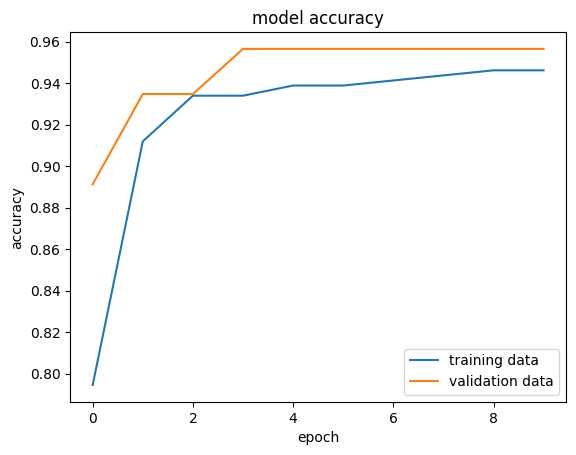

In [74]:
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')

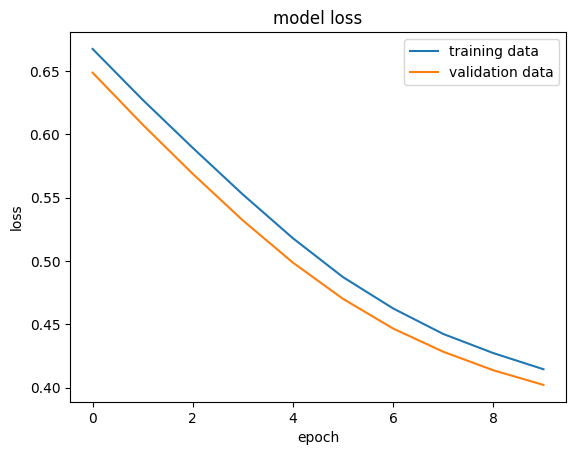

In [76]:
plt.plot(history['loss'])
plt.plot(history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'upper right')

# **Accuracy of the model on test data**

In [79]:
# Evaluate on test data
X_test_tensor = torch.FloatTensor(X_test_std).to(device)
Y_test_tensor = torch.LongTensor(y_test.values).to(device)

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, Y_test_tensor).item()
    _, test_predicted = torch.max(test_outputs.data, 1)
    test_accuracy = (test_predicted == Y_test_tensor).sum().item() / Y_test_tensor.size(0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.4114
Test Accuracy: 0.9474


In [78]:
print(X_test_tensor.shape)
print(X_test_tensor[0])

torch.Size([114, 30])
tensor([-0.0446, -1.4161, -0.0590, -0.1623,  2.0202, -0.1132,  0.1850,  0.4710,
         0.6334,  0.2634,  0.5321,  2.6276,  0.6235,  0.1141,  1.0125,  0.4113,
         0.6385,  2.8897, -0.4168,  0.7427, -0.3298, -1.6744, -0.3685, -0.3877,
         0.3266, -0.7486, -0.5469, -0.1828, -1.2306, -0.6268], device='cuda:0')


In [80]:
model.eval()
with torch.no_grad():
    Y_pred = model(X_test_tensor)

In [81]:
print(Y_pred.shape)
print(Y_pred[0])

torch.Size([114, 2])
tensor([0.4144, 0.7761], device='cuda:0')


In [82]:
print(X_test_tensor)

tensor([[-0.0446, -1.4161, -0.0590,  ..., -0.1828, -1.2306, -0.6268],
        [ 0.2458, -0.0622,  0.2180,  ...,  0.5413,  0.1105,  0.0484],
        [-1.2612, -0.2905, -1.2650,  ..., -1.3514,  0.2693, -0.2823],
        ...,
        [ 0.7271,  0.4584,  0.7528,  ...,  1.4670,  1.1991,  0.6532],
        [ 0.2544,  1.3305,  0.1566,  ..., -1.2904, -2.2256, -1.5956],
        [ 0.8410, -0.0668,  0.8930,  ...,  2.1514,  0.3563,  0.3746]],
       device='cuda:0')


In [83]:
print(Y_pred)

tensor([[4.1436e-01, 7.7605e-01],
        [4.1707e-01, 5.9617e-01],
        [2.6708e-02, 9.8652e-01],
        [9.9926e-01, 3.4342e-04],
        [4.9675e-01, 4.9510e-01],
        [9.7742e-01, 1.1029e-02],
        [2.4272e-01, 7.9431e-01],
        [5.0858e-02, 9.8059e-01],
        [1.0355e-01, 9.4703e-01],
        [1.0227e-01, 9.4984e-01],
        [3.0899e-01, 6.4840e-01],
        [9.0615e-02, 9.1039e-01],
        [1.6245e-01, 9.0659e-01],
        [1.9645e-01, 8.5660e-01],
        [5.7505e-02, 9.7073e-01],
        [8.6140e-01, 1.0061e-01],
        [3.7314e-02, 9.8131e-01],
        [1.4236e-01, 9.3282e-01],
        [8.1766e-02, 9.6965e-01],
        [9.6752e-01, 1.9514e-02],
        [7.9101e-01, 5.9322e-01],
        [6.0949e-02, 9.7489e-01],
        [6.0913e-02, 9.6754e-01],
        [6.1501e-02, 9.7724e-01],
        [2.2154e-01, 8.5093e-01],
        [9.0649e-01, 5.6083e-02],
        [1.7205e-01, 8.7487e-01],
        [3.7664e-01, 7.2160e-01],
        [8.7381e-01, 8.4375e-02],
        [8.886

In [84]:
# argmax function (using PyTorch)

my_list = torch.tensor([0.25, 0.56])

index_of_max_value = torch.argmax(my_list)
print(my_list)
print(index_of_max_value.item())

tensor([0.2500, 0.5600])
1


In [85]:
# converting the prediction probability to class labels

Y_pred_labels = torch.argmax(Y_pred, dim=1)
print(Y_pred_labels.cpu().numpy())

[1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1
 1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0
 1 0 1 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 0
 0 1 0]


# **Building the predictive system**

In [86]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)

# change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardizing the input data
input_data_std = scaler.transform(input_data_reshaped)

# Convert to PyTorch tensor
input_tensor = torch.FloatTensor(input_data_std).to(device)

# Make prediction
model.eval()
with torch.no_grad():
    prediction = model(input_tensor)
print(prediction)

prediction_label = torch.argmax(prediction, dim=1)
print(prediction_label.item())

if prediction_label.item() == 0:
    print('The tumor is Malignant')
else:
    print('The tumor is Benign')

tensor([[0.0412, 0.9814]], device='cuda:0')
1
The tumor is Benign


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
